## Milestone II - Feature Selection

Systematic feature selection to reduce the feature space before final model development.

**Inputs:**
- `data/milestone_ii_preprocessed.pkl` (incomplete — contains NaNs, used by XGBoost)
- `data/milestone_ii_preprocessed_complete.pkl` (complete — NaN-free, used by LSTM / Logistic Regression)

**Outputs:**
- `data/selected_features.pkl` (features selected from incomplete data — for XGBoost)
- `data/selected_features_complete.pkl` (features selected from complete data — for LSTM / LogReg)

**Pipeline (run independently on each dataset):**
1. Correlation-based redundancy removal (|r| > 0.90, model-specific tiebreaker)
2. Permutation importance via cross-validated XGBoost
3. LASSO (L1) logistic regression selection
4. Consensus summary (perm AND lasso) + final feature set

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# ── Load Both Datasets ────────────────────────────────────────────────────
df_incomplete = pd.read_pickle('data/milestone_ii_preprocessed.pkl')
df_complete = pd.read_pickle('data/milestone_ii_preprocessed_complete.pkl')

print(f'Incomplete data shape: {df_incomplete.shape}')
print(f'Complete data shape:   {df_complete.shape}')

Incomplete data shape: (5508, 237)
Complete data shape:   (2070, 237)


### Feature Selection Pipeline

The function below runs the full 3-stage feature selection pipeline on a given dataset:
1. **Correlation removal** — drop one of each pair with |r| > 0.90 (configurable tiebreaker: XGBoost gain or LogReg |coefficients|)
2. **Permutation importance** — 5-fold time-series CV, keep features with mean ROC-AUC drop > 0
3. **LASSO L1** — logistic regression with C=0.05, keep features with non-zero coefficients
4. **Consensus** — intersection of permutation and LASSO selections

In [8]:
def run_feature_selection(df, label, corr_tiebreaker='xgboost'):
    """Run the full 3-stage feature selection pipeline.

    Parameters
    ----------
    df : pd.DataFrame
        Preprocessed data with MultiIndex (date, country).
    label : str
        Label for print/plot titles.
    corr_tiebreaker : str
        Model for correlation tiebreaker: 'xgboost' (gain) or 'logreg' (|coef|).

    Returns
    -------
    dict with keys:
        'selected_features': list of consensus feature names
        'features_after_corr': list after correlation removal
        'features_perm_selected': list from permutation importance
        'features_lasso_selected': list from LASSO
        'perm_df': DataFrame of permutation results
        'gain_importance': Series of XGBoost gain importance
        'eval_results': dict of CV evaluation results per feature set
        'feature_cols': list of all original feature columns
    """
    print(f'\n{"="*70}')
    print(f'  FEATURE SELECTION: {label}')
    print(f'{"="*70}\n')

    # ── Data Setup ──────────────────────────────────────────────────────────
    df_flat = df.reset_index()
    df_flat = df_flat[df_flat['date'] < '2019-01-01']

    leaky_cols = ['oecd_rec', 'technical_rec', 'pre_recession']
    non_feature_cols = ['date', 'country']
    feature_cols = [c for c in df_flat.columns if c not in leaky_cols + non_feature_cols]

    X = df_flat[feature_cols].copy()
    y = df_flat['pre_recession']
    X = X.replace([np.inf, -np.inf], np.nan)

    scale_pos_weight = (y == 0).sum() / (y == 1).sum()

    print(f'Observations: {len(X)}')
    print(f'Features:     {len(feature_cols)}')
    print(f'Positive class: {y.sum()} ({y.mean():.1%})')
    print(f'scale_pos_weight: {scale_pos_weight:.2f}\n')

    # ══════════════════════════════════════════════════════════════════════
    # Step 1: Correlation-Based Redundancy Removal
    # ══════════════════════════════════════════════════════════════════════
    print('─── Step 1: Correlation-Based Redundancy Removal ───')

    model_ref = xgb.XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        scale_pos_weight=scale_pos_weight, random_state=42,
        n_jobs=-1, verbosity=0
    )
    model_ref.fit(X, y)

    gain_importance = pd.Series(
        model_ref.feature_importances_, index=feature_cols
    ).sort_values(ascending=False)

    print('Top 10 features by XGBoost gain importance:')
    print(gain_importance.head(10).to_string())

    # Build tiebreaker importance for correlation removal
    if corr_tiebreaker == 'logreg':
        print(f'\nCorrelation tiebreaker: Logistic Regression |coefficients|')
        _imp = SimpleImputer(strategy='median')
        _scl = StandardScaler()
        X_tb = _scl.fit_transform(_imp.fit_transform(X))
        lr_tb = LogisticRegression(
            penalty='l1', solver='saga', C=0.05, max_iter=5000,
            random_state=42, class_weight='balanced'
        )
        lr_tb.fit(X_tb, y)
        tiebreaker_importance = pd.Series(
            np.abs(lr_tb.coef_[0]), index=feature_cols
        ).sort_values(ascending=False)
        print('Top 10 features by LogReg |coefficient|:')
        print(tiebreaker_importance.head(10).to_string())
    else:
        print(f'\nCorrelation tiebreaker: XGBoost gain importance')
        tiebreaker_importance = gain_importance

    # Identify high-correlation pairs
    corr_matrix = X.corr()
    threshold = 0.90
    corr_upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    high_corr_pairs = []
    for col in corr_upper.columns:
        for row in corr_upper.index:
            val = corr_upper.loc[row, col]
            if pd.notna(val) and abs(val) > threshold:
                imp_row = tiebreaker_importance.get(row, 0)
                imp_col = tiebreaker_importance.get(col, 0)
                drop_feature = row if imp_row < imp_col else col
                keep_feature = col if drop_feature == row else row
                high_corr_pairs.append({
                    'feature_a': row, 'feature_b': col,
                    'correlation': round(val, 4),
                    'drop': drop_feature, 'keep': keep_feature
                })

    pairs_df = pd.DataFrame(high_corr_pairs).sort_values(
        'correlation', key=abs, ascending=False
    )
    print(f'\nHigh-correlation pairs (|r| > {threshold}): {len(pairs_df)}')
    print(pairs_df.head(20).to_string(index=False))

    # Remove redundant features, resolving conflicts
    features_to_drop = set(pairs_df['drop'].tolist())
    keep_set = set(pairs_df['keep'].tolist())
    for feat in features_to_drop & keep_set:
        features_to_drop.discard(feat)

    features_after_corr = [f for f in feature_cols if f not in features_to_drop]

    print(f'\nFeatures before: {len(feature_cols)}')
    print(f'Dropped:         {len(features_to_drop)}')
    print(f'Remaining:       {len(features_after_corr)}')
    print(f'\nDropped features:')
    for f in sorted(features_to_drop):
        print(f'  {f}')

    # Correlation heatmap (before vs after)
    top_n = 40
    top_feats = gain_importance.head(top_n).index.tolist()

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    corr_before = X[top_feats].corr()
    sns.heatmap(corr_before, ax=axes[0], cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, square=True, xticklabels=True,
                yticklabels=True, cbar_kws={'shrink': 0.6})
    axes[0].set_title(f'Top {top_n} Features (Before Removal)')
    axes[0].tick_params(axis='x', rotation=90, labelsize=7)
    axes[0].tick_params(axis='y', labelsize=7)

    top_after = [f for f in top_feats if f in features_after_corr]
    corr_after = X[top_after].corr()
    sns.heatmap(corr_after, ax=axes[1], cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, square=True, xticklabels=True,
                yticklabels=True, cbar_kws={'shrink': 0.6})
    axes[1].set_title(f'After Removal ({len(top_after)} remain)')
    axes[1].tick_params(axis='x', rotation=90, labelsize=7)
    axes[1].tick_params(axis='y', labelsize=7)

    plt.suptitle(f'{label}: Correlation Structure Before vs After', fontsize=12)
    plt.tight_layout()
    plt.show()

    # ══════════════════════════════════════════════════════════════════════
    # Step 2: Permutation Importance (Cross-Validated)
    # ══════════════════════════════════════════════════════════════════════
    print('\n─── Step 2: Permutation Importance (5-fold CV) ───')

    X_reduced = X[features_after_corr].copy()
    tscv = TimeSeriesSplit(n_splits=5)

    fold_importances = []
    fold_roc_aucs = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X_reduced)):
        X_train, X_test = X_reduced.iloc[train_idx], X_reduced.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        spw = (y_train == 0).sum() / (y_train == 1).sum()

        model_fold = xgb.XGBClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1,
            scale_pos_weight=spw, random_state=42, n_jobs=-1, verbosity=0
        )
        model_fold.fit(X_train, y_train)

        y_proba = model_fold.predict_proba(X_test)[:, 1]
        fold_roc_aucs.append(roc_auc_score(y_test, y_proba))

        perm_result = permutation_importance(
            model_fold, X_test, y_test,
            n_repeats=5, scoring='roc_auc', random_state=42, n_jobs=-1
        )
        fold_importances.append(perm_result.importances_mean)
        print(f'  Fold {fold + 1}: ROC-AUC = {fold_roc_aucs[-1]:.3f}')

    perm_mean = np.mean(fold_importances, axis=0)
    perm_std = np.std(fold_importances, axis=0)

    perm_df = pd.DataFrame({
        'feature': features_after_corr,
        'perm_mean': perm_mean,
        'perm_std': perm_std
    }).sort_values('perm_mean', ascending=False).reset_index(drop=True)

    print(f'\nCV ROC-AUC: {np.mean(fold_roc_aucs):.3f} ± {np.std(fold_roc_aucs):.3f}')
    print(f'\nTop 20 by permutation importance:')
    print(perm_df.head(20).to_string(index=False))

    features_perm_selected = perm_df[perm_df['perm_mean'] > 0]['feature'].tolist()
    print(f'\nFeatures with perm_mean > 0: {len(features_perm_selected)}')

    # Permutation importance + gain comparison plot
    top_n_perm = 30
    plot_df = perm_df.head(top_n_perm).sort_values('perm_mean', ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(18, 10))
    axes[0].barh(plot_df['feature'], plot_df['perm_mean'], xerr=plot_df['perm_std'],
                 capsize=3, color='steelblue', alpha=0.8,
                 error_kw={'elinewidth': 1, 'capthick': 1})
    axes[0].axvline(x=0, color='black', linewidth=0.8, linestyle='--')
    axes[0].set_xlabel('Mean ROC-AUC Drop (5-fold CV)')
    axes[0].set_title(f'Top {top_n_perm} Permutation Importance')

    top30_gain = gain_importance[features_after_corr].sort_values(
        ascending=False
    ).head(30).sort_values(ascending=True)
    axes[1].barh(top30_gain.index, top30_gain.values, color='darkorange', alpha=0.8)
    axes[1].set_xlabel('Gain Importance')
    axes[1].set_title('Top 30 XGBoost Gain Importance')

    plt.suptitle(f'{label}: Permutation vs Gain-Based Importance', fontsize=12)
    plt.tight_layout()
    plt.show()

    # ══════════════════════════════════════════════════════════════════════
    # Step 3: LASSO (L1) Feature Selection
    # ══════════════════════════════════════════════════════════════════════
    print('\n─── Step 3: LASSO (L1) Feature Selection ───')

    imputer = SimpleImputer(strategy='median')
    scaler = StandardScaler()

    X_imp = imputer.fit_transform(X_reduced)
    X_scaled = scaler.fit_transform(X_imp)

    C_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]
    lasso_results = {}

    for C in C_values:
        lasso = LogisticRegression(
            penalty='l1', solver='saga', C=C, max_iter=5000,
            random_state=42, class_weight='balanced'
        )
        lasso.fit(X_scaled, y)

        coef = pd.Series(lasso.coef_[0], index=features_after_corr)
        selected = coef[coef != 0].index.tolist()
        lasso_results[C] = {'n_selected': len(selected), 'selected': selected, 'coef': coef}
        print(f'  C={C:6.3f}  ->  {len(selected):3d} features selected')

    C_primary = 0.05
    features_lasso_selected = lasso_results[C_primary]['selected']
    print(f'\nPrimary LASSO (C={C_primary}): {len(features_lasso_selected)} features')

    # LASSO plots
    c_vals = list(lasso_results.keys())
    n_sels = [lasso_results[c]['n_selected'] for c in c_vals]

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    axes[0].semilogx(c_vals, n_sels, 'o-', color='steelblue', linewidth=2, markersize=8)
    axes[0].axvline(x=C_primary, color='red', linestyle='--', label=f'Primary C={C_primary}')
    axes[0].set_xlabel('C (inverse regularization strength)')
    axes[0].set_ylabel('Features Selected')
    axes[0].set_title('LASSO Feature Count vs Regularization')
    axes[0].legend()
    for c, n in zip(c_vals, n_sels):
        axes[0].annotate(str(n), (c, n), textcoords='offset points', xytext=(0, 8),
                         ha='center', fontsize=9)

    coef_primary = lasso_results[C_primary]['coef']
    nonzero_coef = coef_primary[coef_primary != 0].sort_values()
    colors = ['red' if v < 0 else 'steelblue' for v in nonzero_coef.values]
    axes[1].barh(nonzero_coef.index, nonzero_coef.values, color=colors, alpha=0.8)
    axes[1].axvline(x=0, color='black', linewidth=0.8)
    axes[1].set_xlabel('LASSO Coefficient')
    axes[1].set_title(f'LASSO Coefficients (C={C_primary})')
    axes[1].tick_params(axis='y', labelsize=8)

    plt.suptitle(f'{label}: LASSO Feature Selection', fontsize=12)
    plt.tight_layout()
    plt.show()

    # ══════════════════════════════════════════════════════════════════════
    # Step 4: Consensus (Permutation AND LASSO)
    # ══════════════════════════════════════════════════════════════════════
    print('\n─── Step 4: Consensus Feature Selection ───')

    set_perm = set(features_perm_selected)
    set_lasso = set(features_lasso_selected)

    consensus_records = []
    for feat in features_after_corr:
        in_perm = feat in set_perm
        in_lasso = feat in set_lasso
        n_methods = int(in_perm) + int(in_lasso)
        consensus_records.append({
            'feature': feat, 'in_perm': in_perm, 'in_lasso': in_lasso,
            'n_methods': n_methods,
            'perm_mean': perm_df.set_index('feature')['perm_mean'].get(feat, np.nan),
            'gain_importance': gain_importance.get(feat, 0)
        })

    consensus_df = pd.DataFrame(consensus_records).sort_values(
        ['n_methods', 'perm_mean'], ascending=[False, False]
    ).reset_index(drop=True)

    features_consensus_any = consensus_df[consensus_df['n_methods'] >= 1]['feature'].tolist()
    features_consensus_both = consensus_df[consensus_df['n_methods'] >= 2]['feature'].tolist()

    print(f'Corr-reduced (Step 1):    {len(features_after_corr)}')
    print(f'Perm selected (Step 2):   {len(set_perm)}')
    print(f'LASSO selected (Step 3):  {len(set_lasso)}')
    print(f'Perm OR LASSO:            {len(features_consensus_any)}')
    print(f'Perm AND LASSO:           {len(features_consensus_both)}')
    print(f'\nConsensus features (perm AND lasso):')
    for f in features_consensus_both:
        row = consensus_df[consensus_df['feature'] == f].iloc[0]
        print(f'  {f:55s}  perm={row["perm_mean"]:.4f}  gain={row["gain_importance"]:.4f}')

    # ── CV evaluation across feature sets ─────────────────────────────────────
    def run_cv_xgb(X_sub, y_sub, n_splits=5):
        tscv_eval = TimeSeriesSplit(n_splits=n_splits)
        roc_aucs, pr_aucs = [], []
        for tr_idx, te_idx in tscv_eval.split(X_sub):
            X_tr, X_te = X_sub.iloc[tr_idx], X_sub.iloc[te_idx]
            y_tr, y_te = y_sub.iloc[tr_idx], y_sub.iloc[te_idx]
            spw_ = (y_tr == 0).sum() / (y_tr == 1).sum()
            m = xgb.XGBClassifier(
                n_estimators=100, max_depth=6, learning_rate=0.1,
                scale_pos_weight=spw_, random_state=42, n_jobs=-1, verbosity=0
            )
            m.fit(X_tr, y_tr)
            yp = m.predict_proba(X_te)[:, 1]
            roc_aucs.append(roc_auc_score(y_te, yp))
            prec, rec, _ = precision_recall_curve(y_te, yp)
            pr_aucs.append(auc(rec, prec))
        return np.mean(roc_aucs), np.std(roc_aucs), np.mean(pr_aucs), np.std(pr_aucs)

    print(f'\n─── CV Evaluation ───')
    eval_sets = {
        f'All {len(feature_cols)} features': X[feature_cols],
        f'Corr-reduced ({len(features_after_corr)})': X_reduced,
        f'Perm OR LASSO ({len(features_consensus_any)})': X_reduced[features_consensus_any],
        f'Perm AND LASSO ({len(features_consensus_both)})': X_reduced[features_consensus_both],
    }

    eval_results = {}
    for ev_label, X_eval in eval_sets.items():
        roc, roc_std, pr, pr_std = run_cv_xgb(X_eval, y)
        eval_results[ev_label] = {
            'n_features': X_eval.shape[1], 'roc_auc': roc, 'roc_std': roc_std,
            'pr_auc': pr, 'pr_std': pr_std
        }
        print(f'  {ev_label}')
        print(f'    ROC-AUC: {roc:.3f} ± {roc_std:.3f}   PR-AUC: {pr:.3f} ± {pr_std:.3f}')

    # Final comparison plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    labels_short = list(eval_results.keys())
    x = np.arange(len(labels_short))
    width = 0.6

    for ax_i, metric in enumerate(['roc_auc', 'pr_auc']):
        means = [eval_results[k][metric] for k in eval_results]
        stds = [eval_results[k][metric.replace('auc', 'std')] for k in eval_results]
        bars = axes[ax_i].bar(x, means, width, yerr=stds, capsize=5,
                              color='steelblue', alpha=0.8, error_kw={'capthick': 1.5})
        axes[ax_i].set_xticks(x)
        axes[ax_i].set_xticklabels(labels_short, fontsize=8, rotation=15, ha='right')
        axes[ax_i].set_ylabel(metric.upper().replace('_', '-'))
        axes[ax_i].set_title(f'{metric.upper().replace("_", "-")}')
        axes[ax_i].set_ylim(0, max(means) * 1.15)
        for bar, val in zip(bars, means):
            axes[ax_i].text(bar.get_x() + bar.get_width() / 2,
                            bar.get_height() + 0.005,
                            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

    plt.suptitle(f'{label}: Performance vs Complexity', fontsize=12)
    plt.tight_layout()
    plt.show()

    return {
        'selected_features': features_consensus_both,
        'features_after_corr': features_after_corr,
        'features_perm_selected': features_perm_selected,
        'features_lasso_selected': features_lasso_selected,
        'perm_df': perm_df,
        'gain_importance': gain_importance,
        'eval_results': eval_results,
        'feature_cols': feature_cols,
    }

### Run on Incomplete Data (`milestone_ii_preprocessed.pkl`)

This dataset contains NaNs (XGBoost handles them natively via missing-value splits).
The imputer is only used for the LASSO step. **Correlation tiebreaker: XGBoost gain**
(matches the downstream model). Selected features are exported for XGBoost model training.


  FEATURE SELECTION: Incomplete Data

Observations: 5292
Features:     234
Positive class: 1111 (21.0%)
scale_pos_weight: 3.76

─── Step 1: Correlation-Based Redundancy Removal ───
Top 10 features by XGBoost gain importance:
cli_dev                           0.057826
cli                               0.031104
real_gdp_log_6mo                  0.018716
ind_out_log_6mo                   0.014576
epu_rolling_mean_12mo_lag_6mo     0.012282
vix_rolling_mean_12mo_lag_12mo    0.011271
retail_vol_diff_1mo               0.011105
vix_rolling_mean_12mo_lag_6mo     0.010033
vix_rolling_mean_6mo_lag_12mo     0.010001
copper_log_12mo                   0.009798

Correlation tiebreaker: XGBoost gain importance

High-correlation pairs (|r| > 0.9): 443
                  feature_a                       feature_b  correlation                            drop                        keep
         comp_consumer_conf          comp_consumer_conf_dev       1.0000          comp_consumer_conf_dev          comp_co

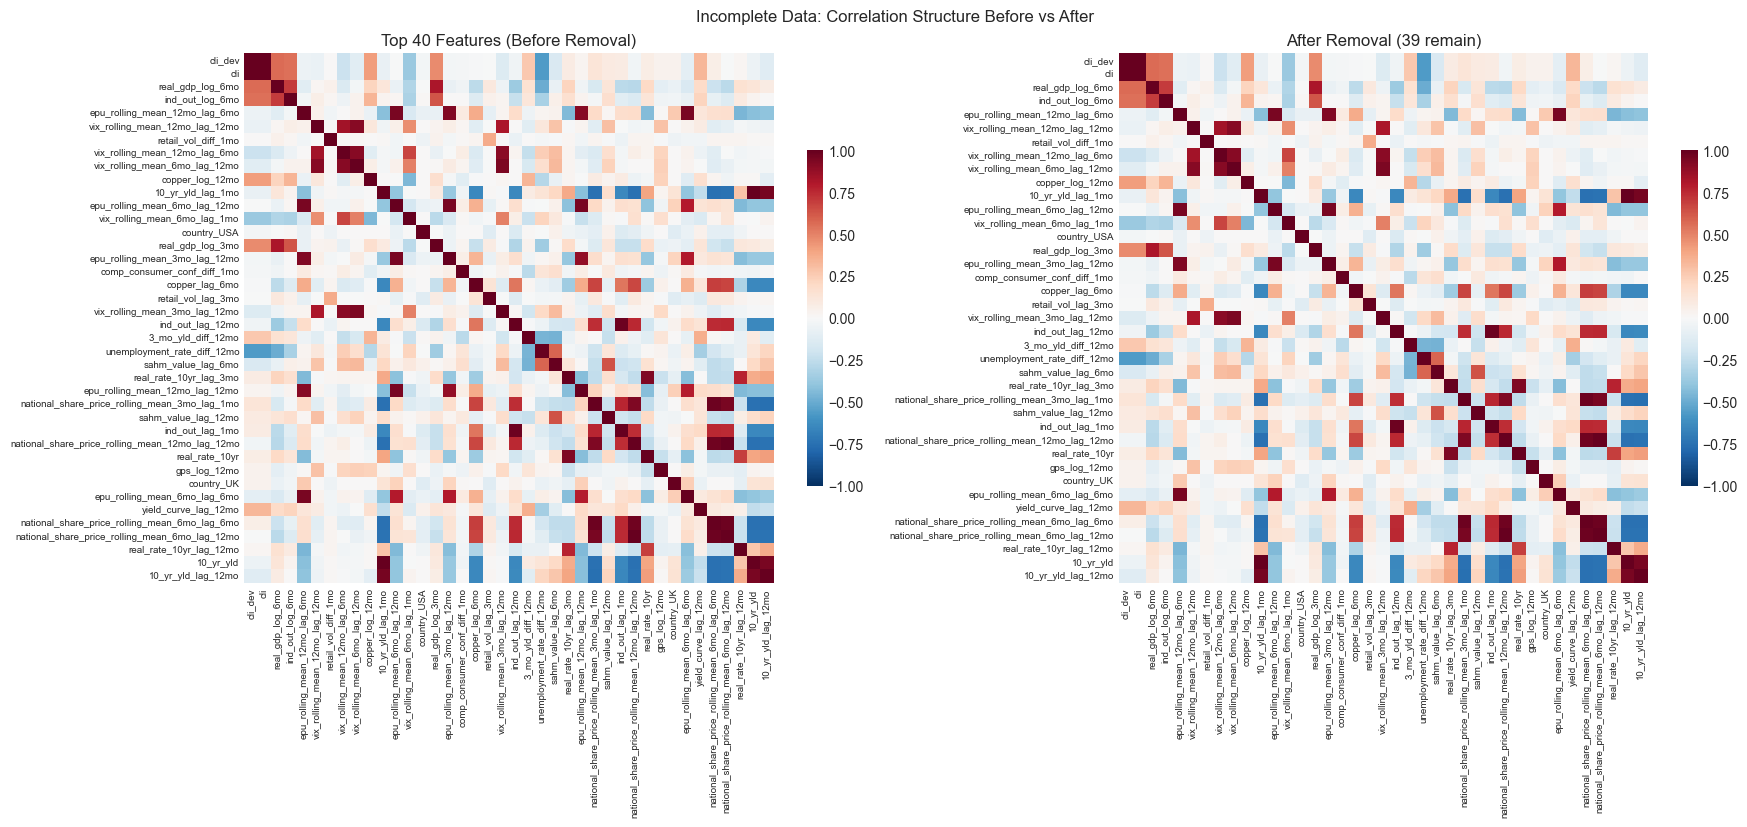


─── Step 2: Permutation Importance (5-fold CV) ───
  Fold 1: ROC-AUC = 0.622
  Fold 2: ROC-AUC = 0.695
  Fold 3: ROC-AUC = 0.713
  Fold 4: ROC-AUC = 0.766
  Fold 5: ROC-AUC = 0.619

CV ROC-AUC: 0.683 ± 0.056

Top 20 by permutation importance:
                   feature  perm_mean  perm_std
                       cli   0.067229  0.041320
             cli_diff_12mo   0.017780  0.017035
            copper_lag_6mo   0.005821  0.006074
               cli_lag_3mo   0.005317  0.003928
           ind_out_log_6mo   0.003978  0.003097
              cli_diff_6mo   0.003359  0.008289
            country_Canada   0.003355  0.006146
comp_consumer_conf_lag_3mo   0.003033  0.002768
               cli_lag_1mo   0.002895  0.002645
              cpi_log_12mo   0.002723  0.002289
         10_yr_yld_lag_6mo   0.002597  0.004171
          real_gdp_log_3mo   0.002591  0.001832
       10_yr_yld_diff_12mo   0.002474  0.002006
unemployment_rate_diff_6mo   0.001661  0.003409
unemployment_rate_diff_3mo   0.00152

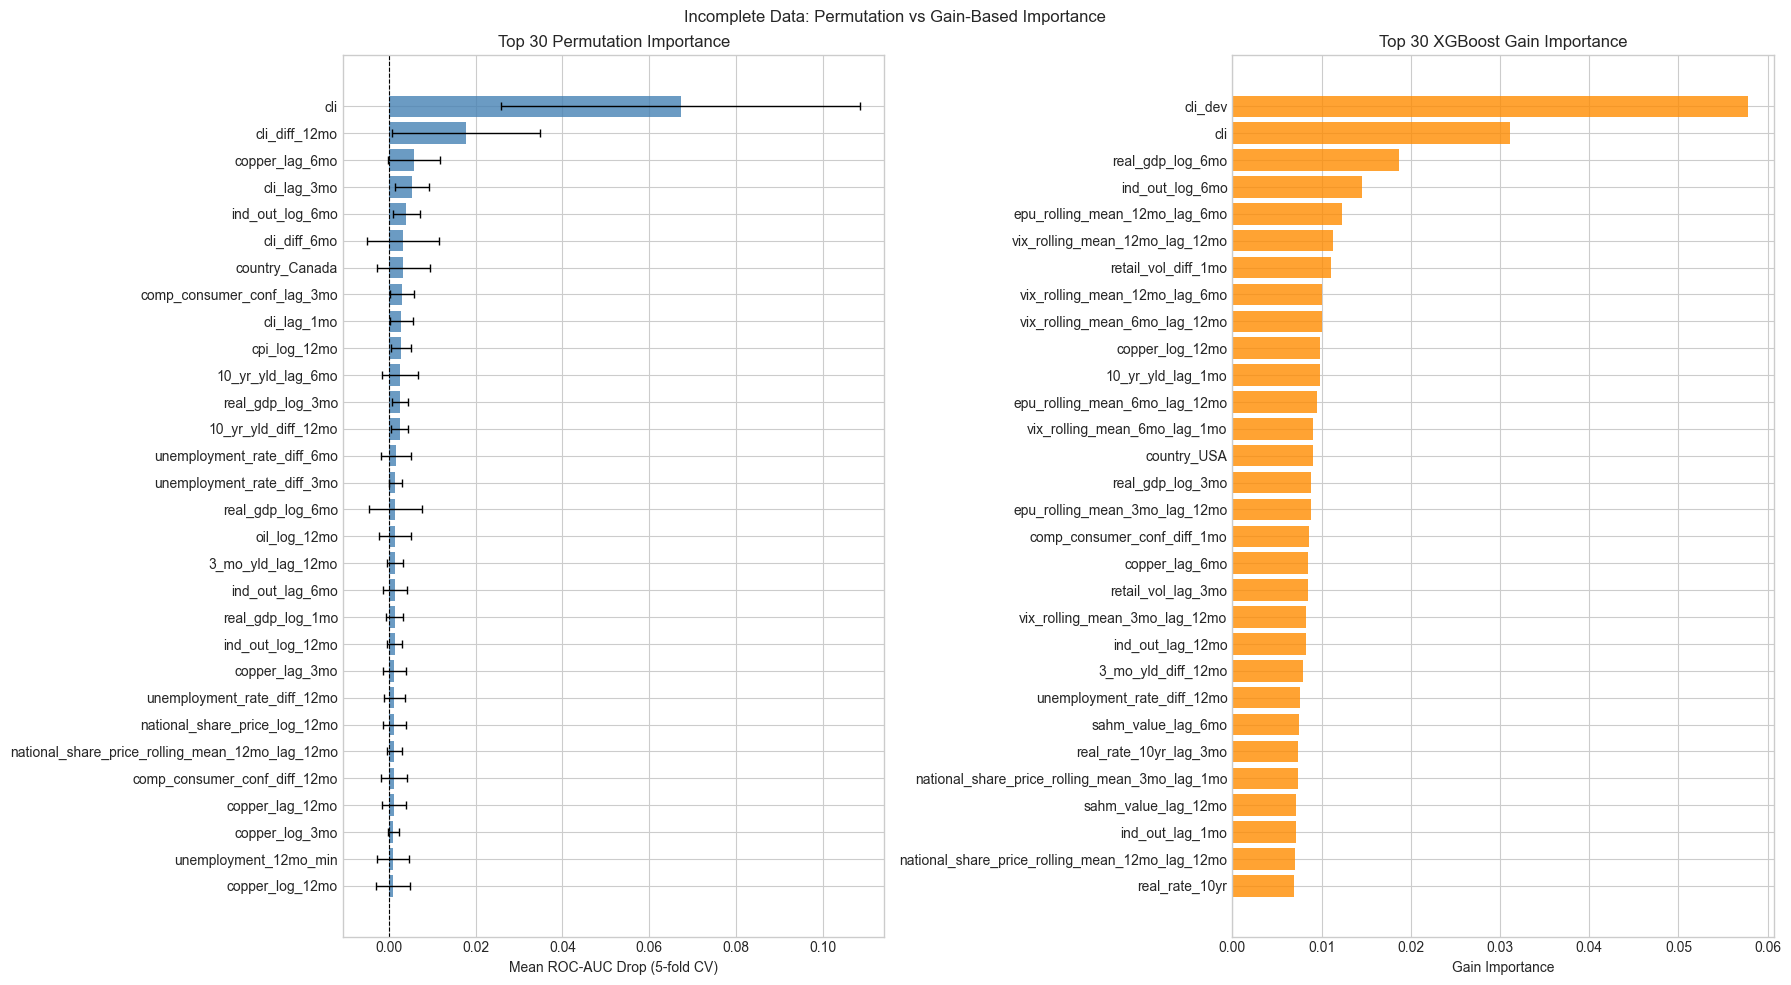


─── Step 3: LASSO (L1) Feature Selection ───
  C= 0.001  ->    2 features selected
  C= 0.005  ->    6 features selected
  C= 0.010  ->   23 features selected
  C= 0.050  ->   72 features selected
  C= 0.100  ->   95 features selected
  C= 0.500  ->  147 features selected
  C= 1.000  ->  158 features selected

Primary LASSO (C=0.05): 72 features


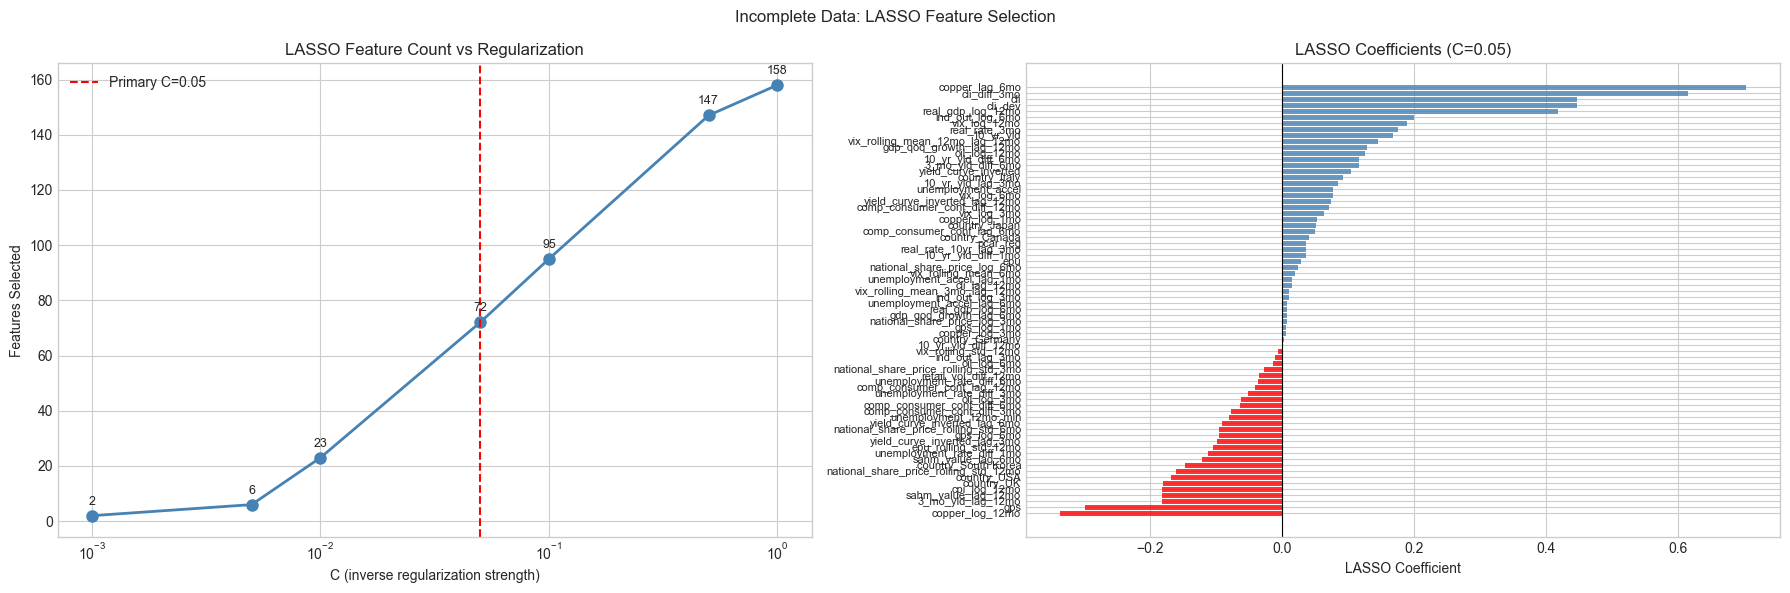


─── Step 4: Consensus Feature Selection ───
Corr-reduced (Step 1):    204
Perm selected (Step 2):   94
LASSO selected (Step 3):  72
Perm OR LASSO:            129
Perm AND LASSO:           37

Consensus features (perm AND lasso):
  cli                                                      perm=0.0672  gain=0.0311
  copper_lag_6mo                                           perm=0.0058  gain=0.0085
  ind_out_log_6mo                                          perm=0.0040  gain=0.0146
  country_Canada                                           perm=0.0034  gain=0.0060
  cpi_log_12mo                                             perm=0.0027  gain=0.0055
  10_yr_yld_diff_12mo                                      perm=0.0025  gain=0.0046
  unemployment_rate_diff_6mo                               perm=0.0017  gain=0.0035
  unemployment_rate_diff_3mo                               perm=0.0015  gain=0.0021
  real_gdp_log_6mo                                         perm=0.0015  gain=0.0187
  oil_log_12mo

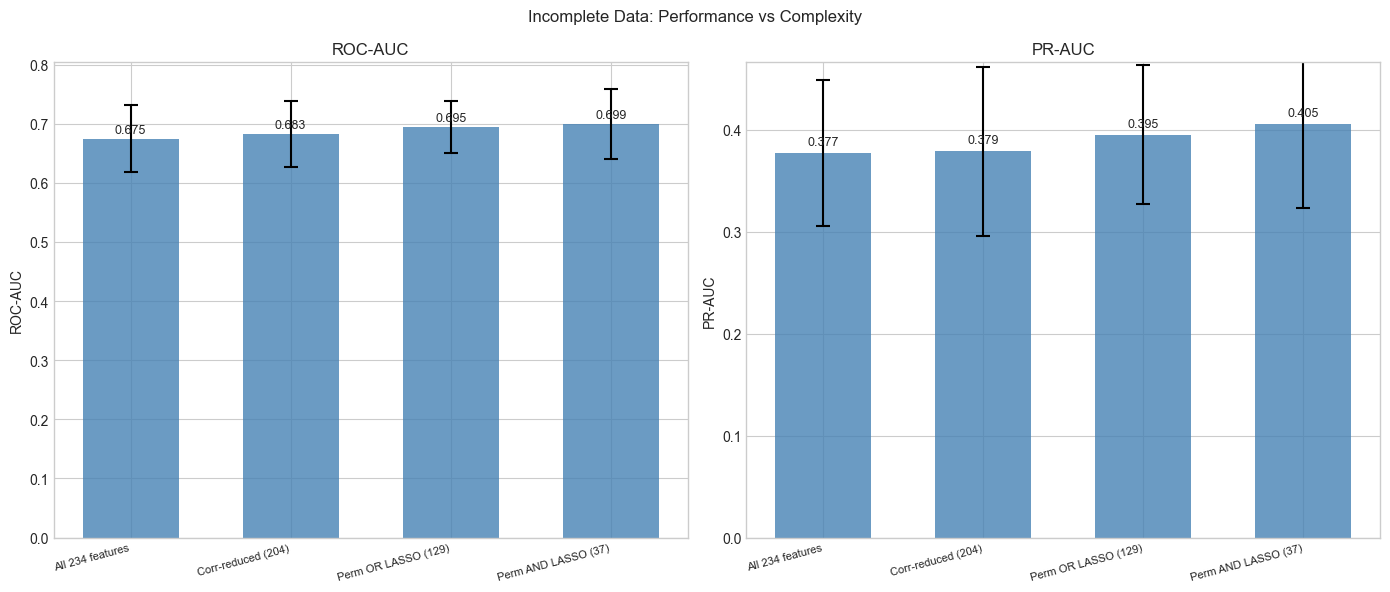

In [9]:
results_incomplete = run_feature_selection(df_incomplete, 'Incomplete Data', corr_tiebreaker='xgboost')

### Run on Complete Data (`milestone_ii_preprocessed_complete.pkl`)

This NaN-free dataset is trimmed to the earliest NaN-free tail across all countries.
It has fewer rows but no missing values. **Correlation tiebreaker: LogReg |coefficients|**
(better aligned with linear/sequential downstream models). Selected features are exported
for LSTM and Logistic Regression model training.


  FEATURE SELECTION: Complete Data

Observations: 1854
Features:     234
Positive class: 336 (18.1%)
scale_pos_weight: 4.52

─── Step 1: Correlation-Based Redundancy Removal ───
Top 10 features by XGBoost gain importance:
copper_lag_3mo                   0.088878
10_yr_yld_lag_3mo                0.050867
gps_log_3mo                      0.042446
vix_rolling_mean_3mo_lag_12mo    0.030080
vix_rolling_mean_12mo            0.022853
10_yr_yld_lag_1mo                0.022500
copper_lag_1mo                   0.019704
real_rate_10yr_lag_3mo           0.019352
country_Germany                  0.016754
comp_consumer_conf_lag_1mo       0.015465

Correlation tiebreaker: Logistic Regression |coefficients|
Top 10 features by LogReg |coefficient|:
cpi                                      0.559494
country_UK                               0.507000
copper                                   0.498184
copper_log_6mo                           0.495841
cli_diff_1mo                             0.450312
nation

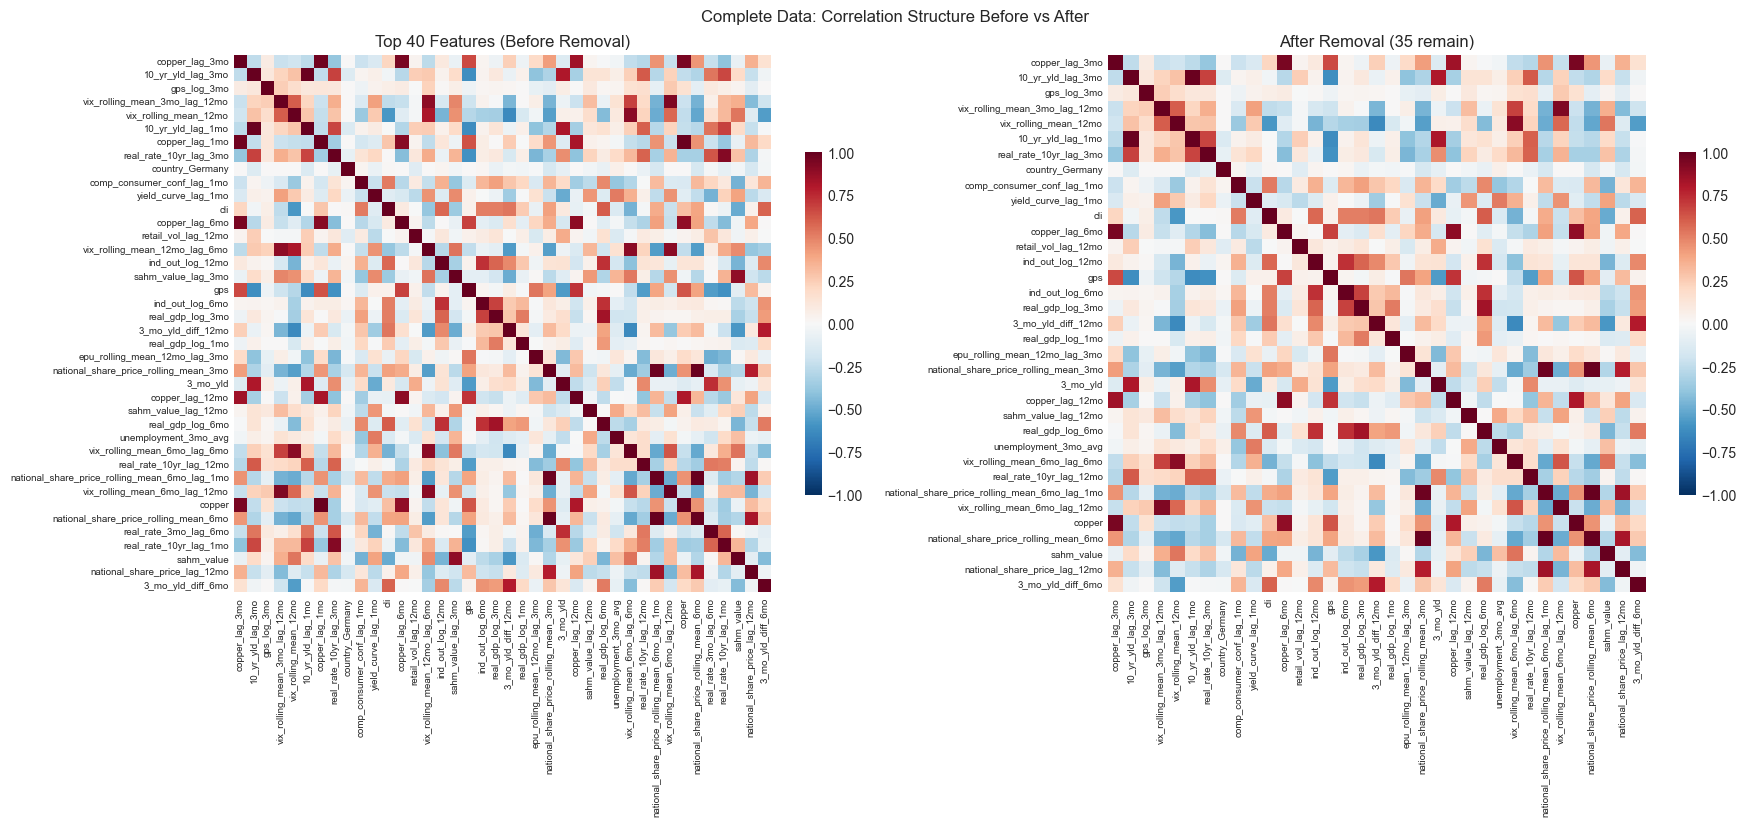


─── Step 2: Permutation Importance (5-fold CV) ───
  Fold 1: ROC-AUC = 0.643
  Fold 2: ROC-AUC = 0.639
  Fold 3: ROC-AUC = 0.514
  Fold 4: ROC-AUC = 0.599
  Fold 5: ROC-AUC = 0.528

CV ROC-AUC: 0.585 ± 0.054

Top 20 by permutation importance:
                              feature  perm_mean  perm_std
                       copper_lag_3mo   0.034181  0.043216
                   comp_consumer_conf   0.010541  0.010725
                       copper_lag_6mo   0.010061  0.012711
                                  cli   0.009130  0.018616
                          cli_lag_1mo   0.006826  0.012305
                               copper   0.006536  0.008451
            unemployment_rate_lag_3mo   0.006306  0.013798
                real_rate_3mo_lag_1mo   0.005840  0.010179
                       real_rate_10yr   0.005590  0.007664
       vix_rolling_mean_12mo_lag_12mo   0.005515  0.011093
        epu_rolling_mean_3mo_lag_12mo   0.004427  0.008116
        national_share_price_log_12mo   0.003465

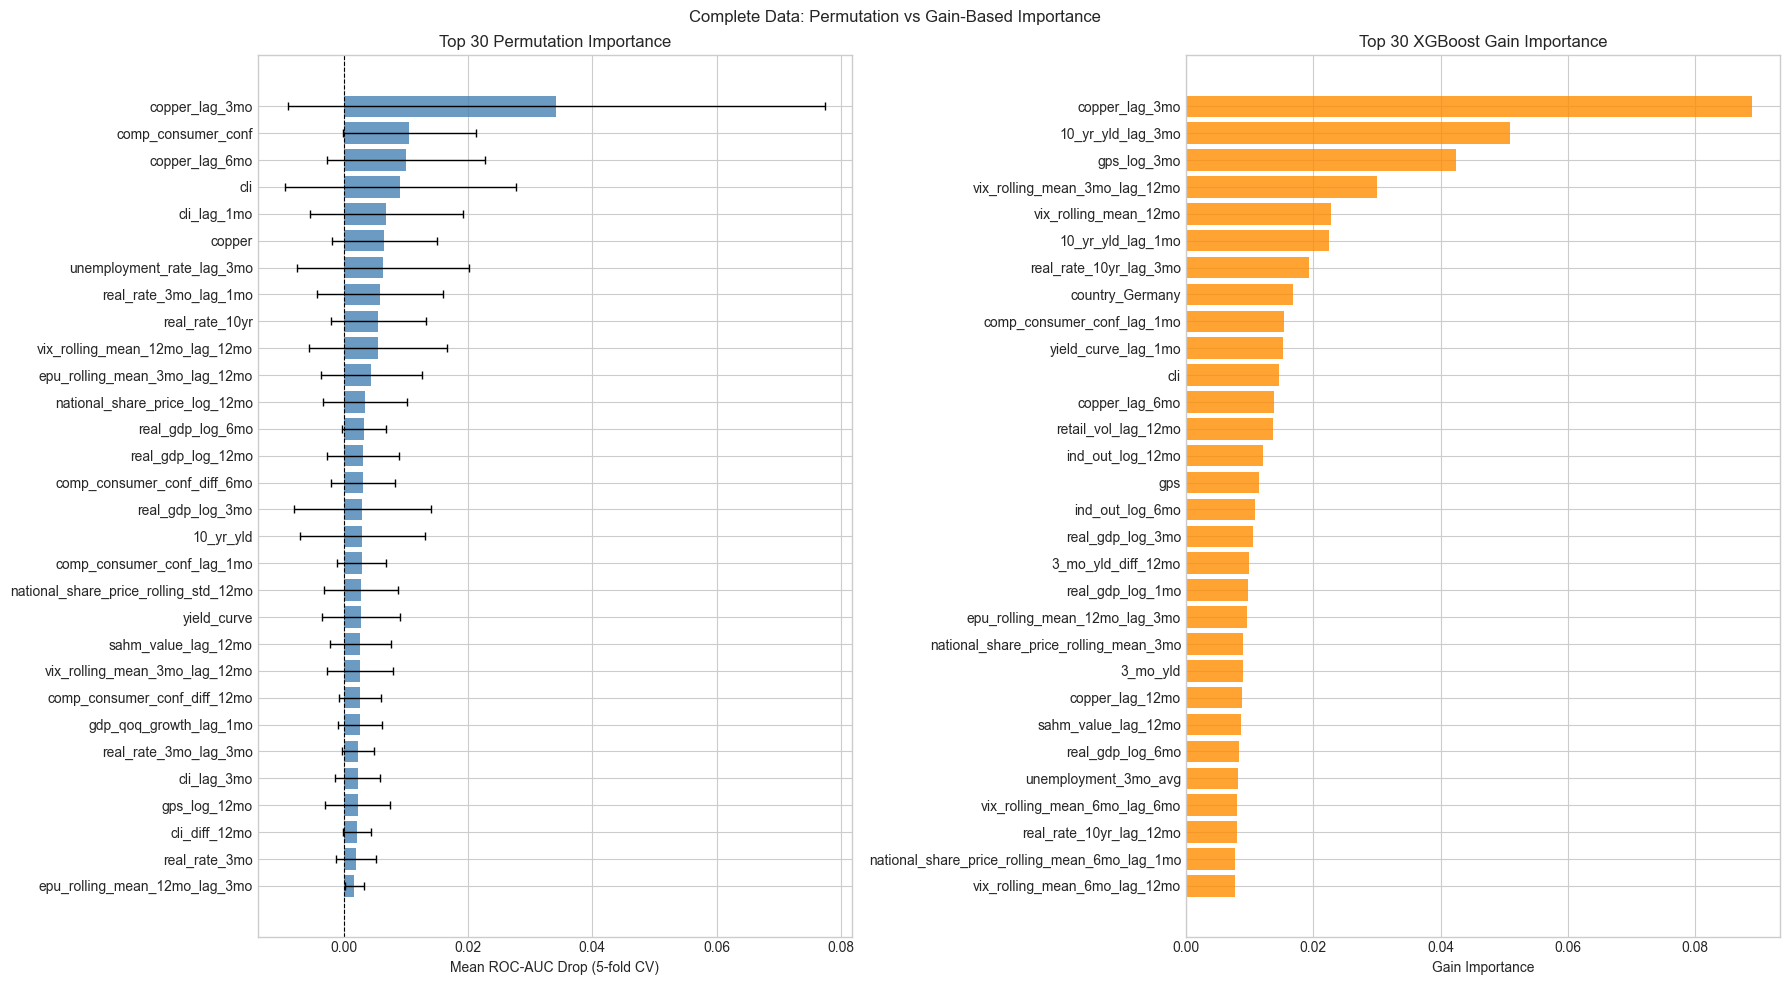


─── Step 3: LASSO (L1) Feature Selection ───
  C= 0.001  ->    0 features selected
  C= 0.005  ->    3 features selected
  C= 0.010  ->    9 features selected
  C= 0.050  ->   43 features selected
  C= 0.100  ->   64 features selected
  C= 0.500  ->  115 features selected
  C= 1.000  ->  136 features selected

Primary LASSO (C=0.05): 43 features


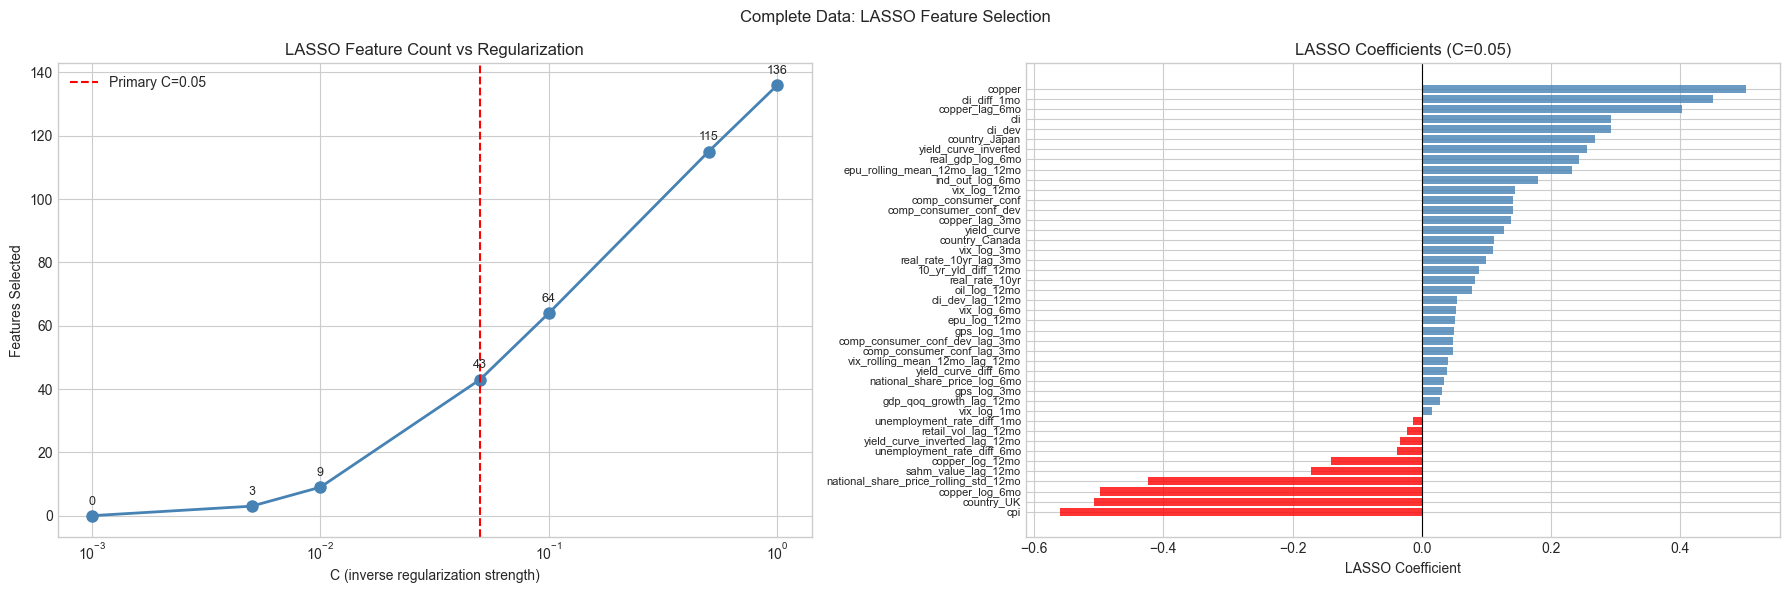


─── Step 4: Consensus Feature Selection ───
Corr-reduced (Step 1):    210
Perm selected (Step 2):   103
LASSO selected (Step 3):  43
Perm OR LASSO:            125
Perm AND LASSO:           21

Consensus features (perm AND lasso):
  copper_lag_3mo                                           perm=0.0342  gain=0.0889
  comp_consumer_conf                                       perm=0.0105  gain=0.0043
  copper_lag_6mo                                           perm=0.0101  gain=0.0138
  cli                                                      perm=0.0091  gain=0.0146
  copper                                                   perm=0.0065  gain=0.0074
  real_rate_10yr                                           perm=0.0056  gain=0.0034
  vix_rolling_mean_12mo_lag_12mo                           perm=0.0055  gain=0.0062
  real_gdp_log_6mo                                         perm=0.0032  gain=0.0083
  national_share_price_rolling_std_12mo                    perm=0.0028  gain=0.0020
  yield_curve

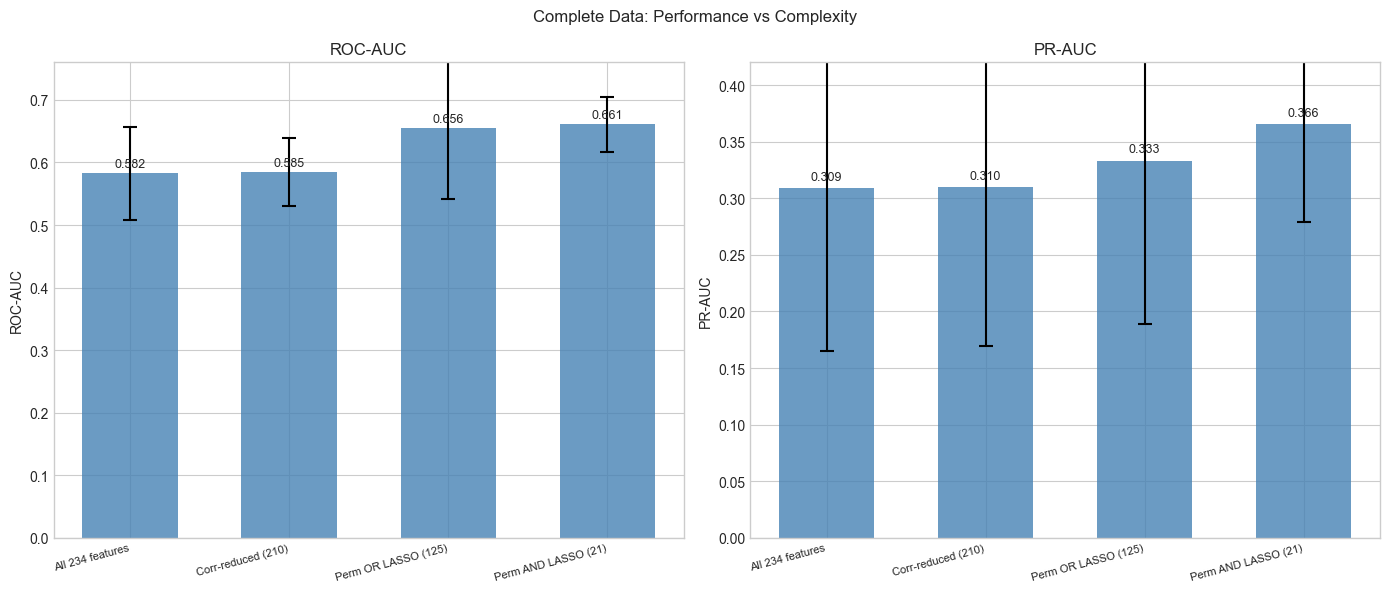

In [10]:
results_complete = run_feature_selection(df_complete, 'Complete Data', corr_tiebreaker='logreg')

### Comparison: Incomplete vs Complete Feature Sets

Compare which features were selected from each dataset to understand how
the presence of NaN rows and additional early-period data affects selection.

Incomplete data selected: 37 features
Complete data selected:   21 features
Shared:                   7 features
Only in incomplete:       30 features
Only in complete:         14 features

Shared features (7):
  cli
  copper_lag_6mo
  gps_log_1mo
  real_gdp_log_6mo
  unemployment_rate_diff_1mo
  unemployment_rate_diff_6mo
  vix_log_3mo

Only in incomplete (30):
  10_yr_yld
  10_yr_yld_diff_12mo
  10_yr_yld_diff_6mo
  3_mo_yld_diff_6mo
  3_mo_yld_lag_12mo
  cli_dev
  cli_lag_12mo
  comp_consumer_conf_diff_12mo
  comp_consumer_conf_lag_6mo
  copper_log_12mo
  copper_log_3mo
  country_Canada
  country_South Korea
  country_USA
  cpi_log_12mo
  epu_rolling_std_12mo
  gps
  ind_out_log_3mo
  ind_out_log_6mo
  national_share_price_rolling_std_6mo
  oil_log_12mo
  oil_log_3mo
  pcar_reg
  retail_vol_diff_12mo
  unemployment_12mo_min
  unemployment_rate_diff_3mo
  vix_log_12mo
  vix_log_6mo
  vix_rolling_mean_3mo_lag_12mo
  yield_curve_inverted_lag_3mo

Only in complete (14):
  comp_consumer_

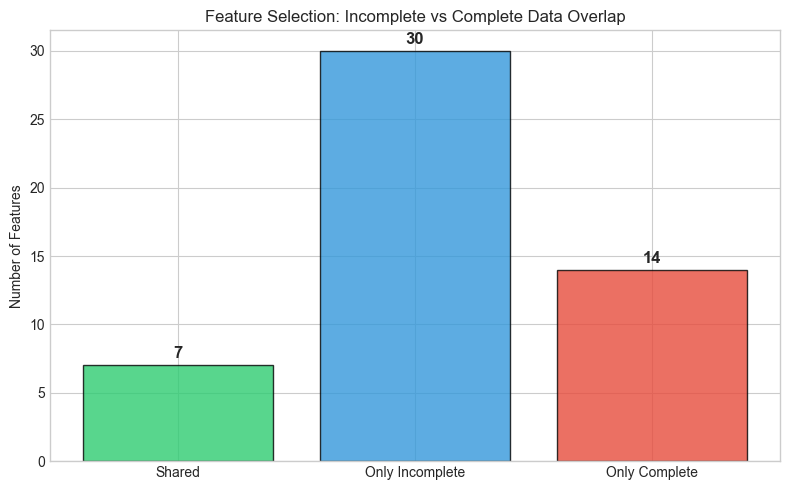

In [11]:
set_inc = set(results_incomplete['selected_features'])
set_comp = set(results_complete['selected_features'])

shared = sorted(set_inc & set_comp)
only_inc = sorted(set_inc - set_comp)
only_comp = sorted(set_comp - set_inc)

print(f'Incomplete data selected: {len(set_inc)} features')
print(f'Complete data selected:   {len(set_comp)} features')
print(f'Shared:                   {len(shared)} features')
print(f'Only in incomplete:       {len(only_inc)} features')
print(f'Only in complete:         {len(only_comp)} features')

print(f'\nShared features ({len(shared)}):')
for f in shared:
    print(f'  {f}')

if only_inc:
    print(f'\nOnly in incomplete ({len(only_inc)}):')
    for f in only_inc:
        print(f'  {f}')

if only_comp:
    print(f'\nOnly in complete ({len(only_comp)}):')
    for f in only_comp:
        print(f'  {f}')

# Overlap bar chart
fig, ax = plt.subplots(figsize=(8, 5))
categories = ['Shared', 'Only Incomplete', 'Only Complete']
counts = [len(shared), len(only_inc), len(only_comp)]
colors_bar = ['#2ecc71', '#3498db', '#e74c3c']
bars = ax.bar(categories, counts, color=colors_bar, alpha=0.8, edgecolor='black')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Features')
ax.set_title('Feature Selection: Incomplete vs Complete Data Overlap')
plt.tight_layout()
plt.show()

In [12]:
# ── Export Both Feature Lists ─────────────────────────────────────────────
with open('data/selected_features.pkl', 'wb') as f:
    pickle.dump(results_incomplete['selected_features'], f)

with open('data/selected_features_complete.pkl', 'wb') as f:
    pickle.dump(results_complete['selected_features'], f)

print(f'Exported data/selected_features.pkl          ({len(results_incomplete["selected_features"])} features)')
print(f'Exported data/selected_features_complete.pkl  ({len(results_complete["selected_features"])} features)')

print(f'\nIncomplete data features ({len(results_incomplete["selected_features"])}):')
for i, f in enumerate(sorted(results_incomplete['selected_features']), 1):
    print(f'  {i:3d}. {f}')

print(f'\nComplete data features ({len(results_complete["selected_features"])}):')
for i, f in enumerate(sorted(results_complete['selected_features']), 1):
    print(f'  {i:3d}. {f}')

Exported data/selected_features.pkl          (37 features)
Exported data/selected_features_complete.pkl  (21 features)

Incomplete data features (37):
    1. 10_yr_yld
    2. 10_yr_yld_diff_12mo
    3. 10_yr_yld_diff_6mo
    4. 3_mo_yld_diff_6mo
    5. 3_mo_yld_lag_12mo
    6. cli
    7. cli_dev
    8. cli_lag_12mo
    9. comp_consumer_conf_diff_12mo
   10. comp_consumer_conf_lag_6mo
   11. copper_lag_6mo
   12. copper_log_12mo
   13. copper_log_3mo
   14. country_Canada
   15. country_South Korea
   16. country_USA
   17. cpi_log_12mo
   18. epu_rolling_std_12mo
   19. gps
   20. gps_log_1mo
   21. ind_out_log_3mo
   22. ind_out_log_6mo
   23. national_share_price_rolling_std_6mo
   24. oil_log_12mo
   25. oil_log_3mo
   26. pcar_reg
   27. real_gdp_log_6mo
   28. retail_vol_diff_12mo
   29. unemployment_12mo_min
   30. unemployment_rate_diff_1mo
   31. unemployment_rate_diff_3mo
   32. unemployment_rate_diff_6mo
   33. vix_log_12mo
   34. vix_log_3mo
   35. vix_log_6mo
   36. vix_rol

### Summary

| Step | Method | Description |
|------|--------|-------------|
| 1 | Correlation removal | Drop one of each pair with \|r\| > 0.90 (model-specific tiebreaker) |
| 2 | Permutation importance | 5-fold CV, keep features with mean ROC-AUC drop > 0 |
| 3 | LASSO L1 (C=0.05) | Keep features with non-zero coefficients |
| 4 | Consensus (perm AND lasso) | Final selected set for downstream modeling |

The pipeline is run independently on both datasets. The correlation tiebreaker is
model-specific to better align feature retention with each downstream model family:

| Output | Dataset | Corr. Tiebreaker | Downstream Models |
|--------|---------|-------------------|-------------------|
| `data/selected_features.pkl` | Incomplete (with NaNs) | XGBoost gain | XGBoost |
| `data/selected_features_complete.pkl` | Complete (NaN-free) | LogReg \|coef\| | LSTM, Logistic Regression |